# Random FDLU noising cluster state - disentangling projectors -Depth 0 Single site projector test

Created: 01-09-2026

Objectives:
* Apply [disentangling projectors](random_fdlu_noising_cluster_state_disentangling_projectors.ipynb), but just check and confirm what happens at depth 0 (i.e. no random unitaries) and with a single site projector. Everything should work cleanly, according to theory.

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from scipy.stats import ortho_group

In [8]:
from collections import Counter

In [9]:
import pandas as pd

In [10]:
from time import time

In [11]:
from humanize import naturalsize

# Definitions
## Construct cluster state

In [12]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [13]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [14]:
np_CZ = np.diag([1,1,1,-1])

In [15]:
np_CZ = np_CZ.reshape((2,)*4)

In [16]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [17]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [18]:
psi = get_cluster_state_qu_tensor_network(12)

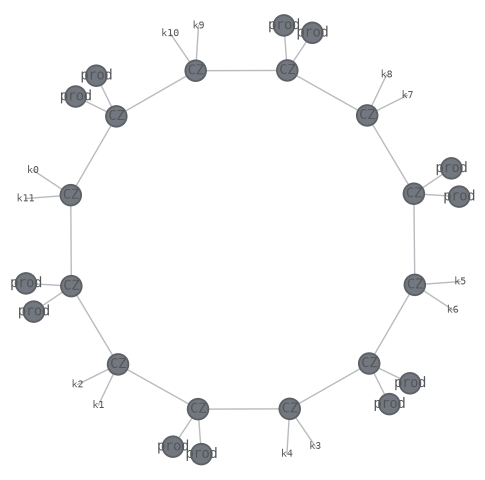

In [19]:
psi.draw()

## Construct product state

In [20]:
np_up_Y_state = 1/(np.sqrt(2))*np.array([1,1j])

In [21]:
qu_up_Y_state = qtn.Tensor(
    data=np_up_Y_state,
    inds=('k',),
    tags='Y'
)

In [22]:
def get_product_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_Y_state.reindex({'k': f'k{i}'})
        for i in range(num_sites)
    ]

    out = qtn.TensorNetwork(
        product_state_tensors,
        virtual=True
    )

    return out

In [23]:
psi = get_product_state_qu_tensor_network(12)

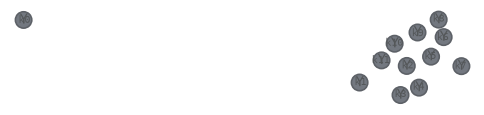

In [24]:
psi.draw()

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [25]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [26]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [27]:
qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

In [28]:
np_I = np.array([
    [1,0],
    [0,1]
])

In [29]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='I'
)

In [30]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [31]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

## Extracting projectors

In [32]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [33]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [34]:
def lanczos_algorithm(rho, v, sites, num_iters=20):
    for _ in range(num_iters):
        v = lanczos_iteration(rho, v, sites)

    return v

In [35]:
def maximize_projector_states(rho):
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20
    )

    new_v = lanczos_iteration(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

In [36]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

## Extract cut rho and EDM

In [37]:
def generate_edm_from_cut_state(cut_state, sites, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        qu_X.reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        qu_X.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        qu_X.reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    edm = (
        cut_state
        & cut_state.reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Defect operators

In [38]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [39]:
def solve_for_boundary_operators(edm, num_iters=100):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])

        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Apply random unitary to groundstate

In [40]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [41]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [42]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [43]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [44]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

## Sweep function

In [45]:
def extract_projector(psi, rho_sites, num_pad_sites):
    rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites}))
    score, proj_vec, overlap = maximize_projector_states(rho)

    larger_sites = list(range(
        min(rho_sites) - num_pad_sites,
        max(rho_sites)  + num_pad_sites
    ))

    larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites}))

    # This is wrong, assumes that we're working with the left side.
    # So be careful of the right side schmidt_vals, likely wrong.
    schmidt_vals = projector_state_check(
        proj_vec,
        larger_rho,
        list(range(min(rho_sites) - num_pad_sites, min(rho_sites)))
    )

    return proj_vec, score, overlap, schmidt_vals

In [46]:
def find_invariants_via_projectors_from_random_state(psi, domains_dict):
    rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

    left_proj_vec, *left_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['left_projector_sites'],
        domains_dict['num_projector_pad_sites']
    )
    
    right_proj_vec, *right_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['right_projector_sites'],
        domains_dict['num_projector_pad_sites']
    )
    
    cut_sites = list(range(
        min(domains_dict['left_projector_sites']),
        max(domains_dict['right_projector_sites'])+1
    ))
    
    cut_rho_unprojected = (
        rand_psi
        & rand_psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites})
    )
    
    left_proj_sites = domains_dict['left_projector_sites']
    right_proj_sites = domains_dict['right_projector_sites']
    
    cut_rho = (
        cut_rho_unprojected.reindex({
            **{f'k{i}': f'l{i}' for i in left_proj_sites},
            **{f'k{i}': f'l{i}' for i in right_proj_sites},
            **{f'b{i}': f'c{i}' for i in left_proj_sites},
            **{f'b{i}': f'c{i}' for i in right_proj_sites}
        })
        & left_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in left_proj_sites})
        & left_proj_vec
        & left_proj_vec.reindex({f'k{i}': f'c{i}' for i in left_proj_sites})
        & left_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in left_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in right_proj_sites})
        & right_proj_vec
        & right_proj_vec.reindex({f'k{i}': f'c{i}' for i in right_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in right_proj_sites})
    )
    
    cut_rho_trace = (
        cut_rho
        .reindex({f'b{i}': f'k{i}' for i in cut_sites})
        .contract()
    )
    
    cut_rho = cut_rho/cut_rho_trace
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in cut_sites}
        | {f'b{i}': f'k{i}' for i in cut_sites}
    )
    
    cut_rho_purity = (
        (cut_rho & cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    sub_cut_sites = list(range(
        max(domains_dict['left_projector_sites'])+1,
        min(domains_dict['right_projector_sites'])
    ))
    
    sub_cut_rho = (
        cut_rho
        .reindex({f'k{i}': f'b{i}' for i in left_proj_sites + right_proj_sites})
    )
    
    sub_cut_rho_trace = (
        sub_cut_rho
        .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
        .contract()
    )
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in sub_cut_sites}
        | {f'b{i}': f'k{i}' for i in sub_cut_sites}
    )
    
    sub_cut_rho_purity = (
        (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    cut_score, cut_state, cut_overlap = maximize_projector_states(sub_cut_rho)

    edm = generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        domains_dict['num_defect_sites']
    )

    defect_ops_results = solve_for_boundary_operators(
        edm,
        num_iters=20
    )

    left_defect_sites = list(range(
        max(domains_dict['left_projector_sites']) + 1,
        max(domains_dict['left_projector_sites']) + 1 + domains_dict['num_defect_sites']
    ))
    right_defect_sites = list(range(
        min(domains_dict['right_projector_sites']) - domains_dict['num_defect_sites'],
        min(domains_dict['right_projector_sites'])
    ))
    
    left_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in left_defect_sites
        })
    )
    left_rdm = left_rdm.contract()
    left_fuse_map = [
        ('k_left', [f'k{i}' for i in left_defect_sites]),
        ('b_left', [f'b{i}' for i in left_defect_sites])
    ]
    left_rdm.fuse(left_fuse_map, inplace=True)
    
    right_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in right_defect_sites
        })
    )
    right_rdm = right_rdm.contract()
    right_fuse_map = [
        ('k_right', [f'k{i}' for i in right_defect_sites]),
        ('b_right', [f'b{i}' for i in right_defect_sites])
    ]
    right_rdm.fuse(right_fuse_map, inplace=True)

    left_defect_op, right_defect_op = defect_ops_results[0]

    np_left_rdm = (
        left_rdm
        .transpose('k_left', 'b_left')
        .data
    )
    
    np_left_defect_op = (
        left_defect_op
        .transpose('k_left', 'b_left')
        .data
        .T
    )
    defect_qu_X = get_multisite_qu_X(domains_dict['num_defect_sites'])

    np_defect_qu_X = (
        defect_qu_X
        .transpose('k', 'b')
        .data
    )

    left_defect_op_invariant = np.trace(
        np_defect_qu_X
        @ np_left_defect_op.conj()
        @ np_defect_qu_X
        @ np_left_defect_op
        @ np_left_rdm
    )

    np_right_rdm = (
        right_rdm
        .transpose('k_right', 'b_right')
        .data
    )
    
    np_right_defect_op = (
        right_defect_op
        .transpose('k_right', 'b_right')
        .data
        .T
    )

    right_defect_op_invariant = np.trace(
        np_defect_qu_X
        @ np_right_defect_op.conj()
        @ np_defect_qu_X
        @ np_right_defect_op
        @ np_right_rdm
    )

    out = {
        'left_proj_vec': left_proj_vec,
        'left_proj_vec_results': left_proj_vec_results,
        'right_proj_vec': right_proj_vec,
        'right_proj_vec_results': right_proj_vec_results,
        'cut_rho_purity': cut_rho_purity,
        'sub_cut_rho_trace': sub_cut_rho_trace,
        'sub_cut_rho_purity': sub_cut_rho_purity,
        'cut_score': cut_score,
        'cut_state': cut_state,
        'cut_overlap': cut_overlap,
        'defect_ops_scores': defect_ops_results[1],
        'left_defect_op': left_defect_op,
        'right_defect_op': right_defect_op,
        'left_defect_op_invariant': left_defect_op_invariant,
        'right_defect_op_invariant': right_defect_op_invariant
    }

    return out

# Sweep
## Depth 0

In [48]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(9, 10)),
    'right_projector_sites': list(range(22, 23)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 0,
    'fdlu_offset': 0
}

In [49]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [50]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(psi, domains_dict)
    results.append(current)

100%|██████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.55it/s]


### Analyze results

#### Projector scores

In [51]:
np.round(np.array([
    d['left_proj_vec_results'][0]
    for d in results
]), 3)

array([0.5+0.j, 0.5+0.j, 0.5-0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j,
       0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5-0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j,
       0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5-0.j, 0.5+0.j])

In [52]:
np.round(np.array([
    d['right_proj_vec_results'][0]
    for d in results
]), 3)

array([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5-0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j,
       0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j,
       0.5+0.j, 0.5-0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5-0.j])

In [53]:
np.round(np.array([
    d['left_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [54]:
np.round(np.array([
    d['right_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [55]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [56]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]), 3)

array([0.632, 0.53 , 0.187, 0.332, 0.988, 0.961, 0.963, 0.535, 0.371,
       0.515, 0.998, 0.909, 0.823, 0.956, 0.961, 0.863, 0.948, 0.493,
       0.957, 0.46 ])

In [57]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]), 3)

array([0.999, 0.861, 0.445, 0.223, 0.253, 0.934, 0.999, 0.883, 0.859,
       0.839, 0.994, 0.59 , 0.953, 0.816, 0.995, 0.822, 0.312, 0.942,
       0.896, 0.965])

I am surprised that we are still seeing entanglement here...!

In [58]:
results[0]['left_proj_vec']

Tensor(shape=(2,), inds=('k9',), tags=oset(['prod', 'CZ']))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [59]:
results[1]['left_proj_vec']

Tensor(shape=(2,), inds=('k9',), tags=oset(['prod', 'CZ']))

#### Purities

In [57]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([0.348+0.j, 0.521-0.j, 0.37 +0.j, 0.44 +0.j, 0.399+0.j, 0.456+0.j,
       0.36 +0.j, 0.342+0.j, 0.604-0.j, 0.395+0.j, 0.449+0.j, 0.643+0.j,
       0.443+0.j, 0.554+0.j, 0.361-0.j, 0.44 +0.j, 0.282+0.j, 0.366-0.j,
       0.537-0.j, 0.293-0.j])

In [58]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j])

In [59]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([0.348+0.j, 0.521-0.j, 0.37 +0.j, 0.44 +0.j, 0.399+0.j, 0.456+0.j,
       0.36 +0.j, 0.342+0.j, 0.604-0.j, 0.395+0.j, 0.449+0.j, 0.643+0.j,
       0.443+0.j, 0.554+0.j, 0.361-0.j, 0.44 +0.j, 0.282+0.j, 0.366-0.j,
       0.537-0.j, 0.293-0.j])

Purities are the same, which one could likely prove.

#### Cut state results

In [60]:
np.round(np.array(
    [d['cut_score'] for d in results]
), 3)

array([0.496+0.j, 0.693-0.j, 0.533+0.j, 0.606+0.j, 0.57 +0.j, 0.633+0.j,
       0.519+0.j, 0.464+0.j, 0.761+0.j, 0.564+0.j, 0.622+0.j, 0.788+0.j,
       0.615+0.j, 0.721-0.j, 0.501+0.j, 0.613+0.j, 0.378+0.j, 0.529-0.j,
       0.688-0.j, 0.411-0.j])

In [61]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [62]:
np.round(np.array([d['defect_ops_scores'][-1] for d in results]), 5)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [63]:
np.array([d['defect_ops_scores'][-1] for d in results])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [64]:
[d['defect_ops_scores'][-1] for d in results]

[np.float64(1.0000000000000009),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(1.000000000000001),
 np.float64(0.9999999999999996),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000004),
 np.float64(1.0),
 np.float64(0.9999999999999996),
 np.float64(0.9999999999999999),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000009),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000007)]

#### Phases

In [65]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [66]:
left_phases.shape

(20,)

In [67]:
left_phases

array([-0.7641497 +0.03364514j, -0.82727916+0.02549956j,
       -0.90956837+0.00883859j, -0.8589881 -0.00234334j,
       -0.77278621-0.05269834j, -0.79152299-0.02642703j,
       -0.71118416-0.01766797j, -0.56255534+0.05910504j,
       -0.84436273-0.00280953j, -0.64630736-0.01315962j,
       -0.77693719-0.03715431j, -0.88390041-0.00811756j,
       -0.76363829+0.01954373j, -0.90287307+0.01123091j,
       -0.78564276+0.00880469j, -0.91810901+0.01789331j,
       -0.99439303+0.00142162j, -0.77329277-0.03029638j,
       -0.9415613 -0.00101648j, -0.64443589+0.03025114j])

In [68]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [69]:
right_phases.shape

(20,)

In [70]:
right_phases

array([-0.75685858-0.01349774j, -0.88588688+0.01578444j,
       -0.70723753+0.08584338j, -0.81437866+0.03785557j,
       -0.81015048+0.00257955j, -0.85824713-0.03016568j,
       -0.78833449-0.00907468j, -0.70974783+0.00297239j,
       -0.87318215-0.03139943j, -0.73671235+0.03488683j,
       -0.8682898 +0.03997846j, -0.92294065-0.00218612j,
       -0.77071536-0.082373j  , -0.86620354-0.02413183j,
       -0.63746354-0.00474465j, -0.69101353+0.06772985j,
       -0.99508919-0.00064239j, -0.640128  +0.01225414j,
       -0.73030788+0.01933622j, -0.62440307+0.03053583j])

## Depth 2

In [142]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [143]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [144]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(psi, domains_dict)
    results.append(current)

100%|███████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.97it/s]


### Analyze results

#### Projector scores

In [145]:
np.round(np.array([
    d['left_proj_vec_results'][0]
    for d in results
]), 3)

array([0.222+0.j, 0.102+0.j, 0.23 +0.j, 0.06 -0.j, 0.16 -0.j, 0.079-0.j,
       0.061+0.j, 0.119-0.j, 0.063+0.j, 0.105-0.j, 0.066+0.j, 0.147+0.j,
       0.079+0.j, 0.102-0.j, 0.099-0.j, 0.124+0.j, 0.097-0.j, 0.167-0.j,
       0.065+0.j, 0.111-0.j])

In [146]:
np.round(np.array([
    d['right_proj_vec_results'][0]
    for d in results
]), 3)

array([0.062+0.j, 0.065+0.j, 0.09 +0.j, 0.077-0.j, 0.109-0.j, 0.129-0.j,
       0.067+0.j, 0.047-0.j, 0.063-0.j, 0.052-0.j, 0.05 +0.j, 0.063+0.j,
       0.058+0.j, 0.073+0.j, 0.124-0.j, 0.038-0.j, 0.033-0.j, 0.07 -0.j,
       0.063-0.j, 0.055-0.j])

In [147]:
np.round(np.array([
    d['left_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [148]:
np.round(np.array([
    d['right_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [149]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [150]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]), 3)

array([0.911, 0.163, 0.595, 0.43 , 0.298, 0.097, 0.455, 0.322, 0.445,
       0.239, 0.657, 0.205, 0.147, 0.138, 0.341, 0.472, 0.095, 0.145,
       0.531, 0.141])

In [151]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]), 3)

array([0.33 , 0.126, 0.177, 0.255, 0.413, 0.283, 0.395, 0.513, 0.442,
       0.472, 0.294, 0.146, 0.363, 0.184, 0.019, 0.157, 0.463, 0.239,
       0.235, 0.212])

#### Purities

In [152]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([0.253-0.j, 0.313-0.j, 0.384-0.j, 0.271+0.j, 0.346+0.j, 0.562+0.j,
       0.364-0.j, 0.317-0.j, 0.203-0.j, 0.426-0.j, 0.303-0.j, 0.436-0.j,
       0.381+0.j, 0.567-0.j, 0.31 -0.j, 0.289+0.j, 0.295+0.j, 0.342+0.j,
       0.263+0.j, 0.381-0.j])

In [153]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j])

In [164]:
purities = np.array(
    [d['sub_cut_rho_purity'] for d in results]
)

In [165]:
np.round(purities, 3)

array([0.253-0.j, 0.313-0.j, 0.384-0.j, 0.271+0.j, 0.346+0.j, 0.562+0.j,
       0.364-0.j, 0.317-0.j, 0.203-0.j, 0.426-0.j, 0.303-0.j, 0.436-0.j,
       0.381+0.j, 0.567-0.j, 0.31 -0.j, 0.289+0.j, 0.295+0.j, 0.342+0.j,
       0.263+0.j, 0.381-0.j])

In [166]:
np.min(purities), np.max(purities)

(np.complex128(0.20348298595604053-6.938893903907228e-18j),
 np.complex128(0.5670315781179642-1.1069704181077e-16j))

Purities are the same, which one could likely prove.

#### Cut state results

In [155]:
np.round(np.array(
    [d['cut_score'] for d in results]
), 3)

array([0.329+0.j, 0.449-0.j, 0.539-0.j, 0.401+0.j, 0.5  -0.j, 0.727-0.j,
       0.529-0.j, 0.45 -0.j, 0.296-0.j, 0.597-0.j, 0.423+0.j, 0.626-0.j,
       0.547-0.j, 0.728-0.j, 0.446-0.j, 0.397+0.j, 0.436-0.j, 0.48 +0.j,
       0.352+0.j, 0.521-0.j])

In [156]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [157]:
np.round(np.array([d['defect_ops_scores'][-1] for d in results]), 5)

array([0.64004, 0.00145, 0.63187, 0.34991, 0.87785, 0.68558, 0.63386,
       0.50302, 0.18351, 0.09514, 0.39266, 0.56704, 0.32795, 0.42329,
       0.61021, 0.70512, 0.32731, 0.62293, 0.24846, 0.1783 ])

In [158]:
np.array([d['defect_ops_scores'][-1] for d in results])

array([0.64004418, 0.0014518 , 0.63187219, 0.34991242, 0.87784647,
       0.68558148, 0.63386364, 0.50302464, 0.18351163, 0.09514452,
       0.39265754, 0.56703807, 0.32795124, 0.42328895, 0.61020682,
       0.70512007, 0.32730749, 0.62292707, 0.2484582 , 0.17830022])

In [159]:
[d['defect_ops_scores'][-1] for d in results]

[np.float64(0.6400441811443376),
 np.float64(0.001451796089796361),
 np.float64(0.6318721867168847),
 np.float64(0.34991242066243256),
 np.float64(0.8778464709182321),
 np.float64(0.6855814768933939),
 np.float64(0.6338636401264302),
 np.float64(0.5030246392340254),
 np.float64(0.18351163255812933),
 np.float64(0.09514452107436425),
 np.float64(0.3926575388781252),
 np.float64(0.5670380690421347),
 np.float64(0.327951243411287),
 np.float64(0.42328895259904126),
 np.float64(0.6102068211085309),
 np.float64(0.7051200745772959),
 np.float64(0.3273074943158037),
 np.float64(0.6229270672477252),
 np.float64(0.24845820486649187),
 np.float64(0.1783002183241338)]

#### Phases

In [160]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [161]:
left_phases.shape

(20,)

In [162]:
left_phases

array([-1.+1.11758123e-16j, -1.+2.02716609e-15j, -1.+3.49361293e-17j,
       -1.+3.01030615e-17j, -1.-6.49266161e-17j, -1.-1.58647405e-16j,
       -1.-1.21443177e-17j, -1.+3.60322635e-17j, -1.-5.72478633e-17j,
       -1.-3.38849551e-17j, -1.+2.98841947e-17j, -1.+2.23938736e-17j,
       -1.-5.23281846e-18j, -1.-1.26306364e-16j, -1.-3.08619502e-17j,
       -1.+1.15003517e-17j, -1.-4.95163290e-17j, -1.-2.26487384e-18j,
       -1.-9.20457607e-17j, -1.+5.40513293e-17j])

In [94]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [95]:
right_phases.shape

(20,)

In [96]:
right_phases

array([-1.-4.91671957e-17j, -1.-3.98378308e-17j, -1.+6.42530784e-15j,
       -1.+1.16951736e-18j, -1.-2.31515269e-17j, -1.-7.25332917e-17j,
       -1.-1.18986809e-16j, -1.+5.17540163e-17j, -1.+1.08733888e-17j,
       -1.-3.15411026e-17j, -1.+9.52081849e-17j, -1.+7.43315150e-17j,
       -1.+5.81939850e-17j, -1.+5.60205358e-17j, -1.+5.53454038e-17j,
       -1.+6.22010500e-17j, -1.-4.63220792e-17j, -1.+8.16507746e-17j,
       -1.-5.82013314e-17j, -1.-1.34759058e-16j])

### Make plots

In [97]:
left_phases_scaled = left_phases/np.abs(left_phases)

In [98]:
left_phases_scaled

array([-1.+4.67054436e-16j, -1.+2.14974966e-18j, -1.+6.13455187e-17j,
       -1.-1.04047576e-16j, -1.+6.09259985e-17j, -1.-1.12918280e-17j,
       -1.-8.14312083e-17j, -1.+1.27784320e-17j, -1.-2.55690980e-17j,
       -1.-3.74000677e-17j, -1.+5.35086813e-18j, -1.-3.26711032e-16j,
       -1.-1.17702456e-17j, -1.-6.83960101e-17j, -1.+1.13641160e-16j,
       -1.-1.32974363e-18j, -1.-6.86191692e-17j, -1.-3.13396233e-17j,
       -1.-6.99113326e-17j, -1.-2.87471232e-17j])

In [99]:
log_left_phase = np.imag(np.log(-left_phases_scaled)) + np.pi

In [100]:
log_left_phase

array([3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265])

In [101]:
right_phases_scaled =right_phases/np.abs(right_phases)

In [102]:
right_phases_scaled

array([-1.-4.91671957e-17j, -1.-3.98378308e-17j, -1.+6.42530784e-15j,
       -1.+1.16951736e-18j, -1.-2.31515269e-17j, -1.-7.25332917e-17j,
       -1.-1.18986809e-16j, -1.+5.17540163e-17j, -1.+1.08733888e-17j,
       -1.-3.15411026e-17j, -1.+9.52081849e-17j, -1.+7.43315150e-17j,
       -1.+5.81939850e-17j, -1.+5.60205358e-17j, -1.+5.53454038e-17j,
       -1.+6.22010500e-17j, -1.-4.63220792e-17j, -1.+8.16507746e-17j,
       -1.-5.82013314e-17j, -1.-1.34759058e-16j])

In [103]:
log_right_phase = np.imag(np.log(-right_phases_scaled)) + np.pi

In [104]:
log_right_phase

array([3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265])

In [105]:
purities = np.real(np.array([d['sub_cut_rho_purity'] for d in results]))

In [106]:
purities

array([0.28688054, 0.38484777, 0.32537027, 0.3389072 , 0.37784661,
       0.34452931, 0.44505931, 0.44190517, 0.32194883, 0.2658259 ,
       0.44583826, 0.33957101, 0.33731515, 0.2744904 , 0.26048361,
       0.33999247, 0.4587457 , 0.50339969, 0.32011525, 0.279     ])

## Depth 2 - product state

In [107]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 4,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [108]:
psi = get_product_state_qu_tensor_network(domains_dict['num_system_sites'])

In [109]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(psi, domains_dict)
    results.append(current)

100%|███████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  7.59it/s]


### Analyze results

#### Projector scores

In [110]:
np.round(np.array([
    d['left_proj_vec_results'][0]
    for d in results
]), 3)

array([0.714+0.j, 0.762+0.j, 0.619-0.j, 0.54 +0.j, 0.759+0.j, 0.603+0.j,
       0.898+0.j, 0.585+0.j, 0.362+0.j, 0.664+0.j, 0.447-0.j, 0.65 -0.j,
       0.374-0.j, 0.552+0.j, 0.752+0.j, 0.515+0.j, 0.698+0.j, 0.449+0.j,
       0.679+0.j, 0.724-0.j])

In [111]:
np.round(np.array([
    d['right_proj_vec_results'][0]
    for d in results
]), 3)

array([0.543-0.j, 0.606+0.j, 0.78 -0.j, 0.51 +0.j, 0.397-0.j, 0.681-0.j,
       0.624+0.j, 0.726+0.j, 0.559-0.j, 0.617+0.j, 0.558-0.j, 0.561+0.j,
       0.826+0.j, 0.685+0.j, 0.57 +0.j, 0.698-0.j, 0.653+0.j, 0.787-0.j,
       0.713+0.j, 0.777-0.j])

In [112]:
np.round(np.array([
    d['left_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [113]:
np.round(np.array([
    d['right_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [114]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [115]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]), 3)

array([0.024, 0.079, 0.05 , 0.002, 0.   , 0.001, 0.007, 0.004, 0.051,
       0.001, 0.   , 0.011, 0.307, 0.05 , 0.002, 0.   , 0.003, 0.013,
       0.004, 0.318])

In [116]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]), 3)

array([0.001, 0.003, 0.038, 0.002, 0.27 , 0.11 , 0.044, 0.002, 0.032,
       0.048, 0.003, 0.283, 0.039, 0.039, 0.325, 0.002, 0.   , 0.001,
       0.001, 0.015])

#### Purities

In [117]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [118]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j])

In [119]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [120]:
np.array(
    [d['sub_cut_rho_purity'] for d in results]
)

array([1.-8.06646416e-17j, 1.-3.12250226e-17j, 1.-1.59594560e-16j,
       1.+6.59194921e-17j, 1.+2.10172591e-16j, 1.+5.06322415e-17j,
       1.+4.85722573e-17j, 1.+2.49800181e-16j, 1.-8.41340886e-17j,
       1.+1.19576276e-16j, 1.+2.77555756e-17j, 1.+1.17961196e-16j,
       1.+3.46944695e-17j, 1.+8.80372164e-17j, 1.-3.46944695e-17j,
       1.+1.73472348e-16j, 1.+3.09648140e-16j, 1.+1.30971622e-16j,
       1.-3.90312782e-17j, 1.-1.25767452e-17j])

#### Cut state results

In [121]:
np.round(np.array(
    [d['cut_score'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j])

In [122]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [123]:
np.round(np.array([d['defect_ops_scores'][-1] for d in results]), 5)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [124]:
np.array([d['defect_ops_scores'][-1] for d in results])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [125]:
[d['defect_ops_scores'][-1] for d in results]

[np.float64(1.0000000000000009),
 np.float64(1.000000000000001),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000004),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000016),
 np.float64(1.000000000000001),
 np.float64(1.0000000000000018),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000007),
 np.float64(1.0),
 np.float64(1.000000000000001),
 np.float64(1.0),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000013),
 np.float64(0.9999999999999998)]

#### Phases

In [126]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [127]:
left_phases.shape

(20,)

In [128]:
left_phases

array([1.+7.52504070e-17j, 1.-7.30074638e-17j, 1.-4.88975180e-17j,
       1.-4.26633555e-17j, 1.+3.22821197e-17j, 1.+4.77048956e-17j,
       1.+4.42896587e-17j, 1.+7.78457160e-17j, 1.-7.99057001e-17j,
       1.-4.31512465e-17j, 1.+1.13841228e-18j, 1.+2.35813973e-17j,
       1.+3.12250226e-17j, 1.-4.64038530e-17j, 1.-6.28837260e-17j,
       1.-1.15196481e-18j, 1.+1.23551614e-16j, 1.+6.11490025e-17j,
       1.+3.87602277e-18j, 1.-2.55871713e-17j])

In [129]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [130]:
right_phases.shape

(20,)

In [131]:
right_phases

array([1.+7.37257477e-18j, 1.+2.29850861e-17j, 1.+6.39950332e-17j,
       1.-3.75405002e-17j, 1.+2.14129929e-17j, 1.+8.71698547e-17j,
       1.+1.46367293e-18j, 1.+9.19403442e-17j, 1.+3.58870919e-17j,
       1.+2.12300338e-17j, 1.+7.43762690e-17j, 1.+2.12503626e-17j,
       1.+1.03216047e-16j, 1.+7.50267903e-17j, 1.-2.84060969e-17j,
       1.+5.99428276e-17j, 1.+2.01119503e-16j, 1.+2.44758640e-17j,
       1.-2.69288715e-17j, 1.+4.33680869e-17j])

### Make plots

In [132]:
left_phases_scaled = left_phases/np.abs(left_phases)

In [133]:
left_phases_scaled

array([1.+7.52504070e-17j, 1.-7.30074638e-17j, 1.-4.88975180e-17j,
       1.-4.26633555e-17j, 1.+3.22821197e-17j, 1.+4.77048956e-17j,
       1.+4.42896587e-17j, 1.+7.78457160e-17j, 1.-7.99057001e-17j,
       1.-4.31512465e-17j, 1.+1.13841228e-18j, 1.+2.35813973e-17j,
       1.+3.12250226e-17j, 1.-4.64038530e-17j, 1.-6.28837260e-17j,
       1.-1.15196481e-18j, 1.+1.23551614e-16j, 1.+6.11490025e-17j,
       1.+3.87602277e-18j, 1.-2.55871713e-17j])

In [134]:
log_left_phase = np.imag(np.log(left_phases_scaled))

In [135]:
log_left_phase

array([ 7.52504070e-17, -7.30074638e-17, -4.88975180e-17, -4.26633555e-17,
        3.22821197e-17,  4.77048956e-17,  4.42896587e-17,  7.78457160e-17,
       -7.99057001e-17, -4.31512465e-17,  1.13841228e-18,  2.35813973e-17,
        3.12250226e-17, -4.64038530e-17, -6.28837260e-17, -1.15196481e-18,
        1.23551614e-16,  6.11490025e-17,  3.87602277e-18, -2.55871713e-17])

In [136]:
right_phases_scaled =right_phases/np.abs(right_phases)

In [137]:
right_phases_scaled

array([1.+7.37257477e-18j, 1.+2.29850861e-17j, 1.+6.39950332e-17j,
       1.-3.75405002e-17j, 1.+2.14129929e-17j, 1.+8.71698547e-17j,
       1.+1.46367293e-18j, 1.+9.19403442e-17j, 1.+3.58870919e-17j,
       1.+2.12300338e-17j, 1.+7.43762690e-17j, 1.+2.12503626e-17j,
       1.+1.03216047e-16j, 1.+7.50267903e-17j, 1.-2.84060969e-17j,
       1.+5.99428276e-17j, 1.+2.01119503e-16j, 1.+2.44758640e-17j,
       1.-2.69288715e-17j, 1.+4.33680869e-17j])

In [138]:
log_right_phase = np.imag(np.log(right_phases_scaled))

In [139]:
log_right_phase

array([ 7.37257477e-18,  2.29850861e-17,  6.39950332e-17, -3.75405002e-17,
        2.14129929e-17,  8.71698547e-17,  1.46367293e-18,  9.19403442e-17,
        3.58870919e-17,  2.12300338e-17,  7.43762690e-17,  2.12503626e-17,
        1.03216047e-16,  7.50267903e-17, -2.84060969e-17,  5.99428276e-17,
        2.01119503e-16,  2.44758640e-17, -2.69288715e-17,  4.33680869e-17])

In [140]:
purities = np.real(np.array([d['sub_cut_rho_purity'] for d in results]))

In [141]:
purities

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])